# GT Data Visualization

Visualize one sample from `data/*/*.h5`:
- Point cloud (`data`)
- RGB image (`image`)
- Nutrition values (`weight`, `volume`, `energy`, `protein`, `fat`, `carb`)

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd()  # if opened from project root
DATA_DIR = os.path.join(BASE_DIR, 'data', 'gt')

# If notebook is opened from data/ folder, fallback to local ./gt
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(BASE_DIR, 'gt')

SPLIT = 'train'   # 'train' or 'test'
SAMPLE_IDX = 0    # change to inspect a different sample

h5_path = os.path.join(DATA_DIR, f'{SPLIT}.h5')
print('Using H5:', h5_path)
assert os.path.exists(h5_path), f'File not found: {h5_path}'

Using H5: /home/ma859/MFP3D/data/gt/train.h5


In [2]:
with h5py.File(h5_path, 'r') as f:
    keys = sorted(list(f.keys()))
    print('Keys:', keys)
    
    points = f['data'][SAMPLE_IDX].astype(np.float32)            # (1024, 3)
    image = f['image'][SAMPLE_IDX].astype(np.float32)            # (3, 224, 224)
    image_path_raw = f['image_path'][SAMPLE_IDX]
    image_path = image_path_raw.decode('utf-8') if isinstance(image_path_raw, (bytes, bytearray)) else str(image_path_raw)
    
    nutrition = {
        'weight': float(f['weight'][SAMPLE_IDX]),
        'volume': float(f['volume'][SAMPLE_IDX]),
        'energy': float(f['energy'][SAMPLE_IDX]),
        'protein': float(f['protein'][SAMPLE_IDX]),
        'fat': float(f['fat'][SAMPLE_IDX]),
        'carb': float(f['carb'][SAMPLE_IDX]),
    }

print('Sample index:', SAMPLE_IDX)
print('Point cloud shape:', points.shape)
print('Image shape:', image.shape)
print('Image path:', image_path)
print('Nutrition values:')
for k, v in nutrition.items():
    print(f'  {k:>7}: {v:.4f}')

Keys: ['carb', 'data', 'energy', 'fat', 'image', 'image_path', 'protein', 'volume', 'weight']
Sample index: 0
Point cloud shape: (1024, 3)
Image shape: (3, 224, 224)
Image path: /pub/public_dataset/MetaFood3D/images/Almond(bowl)/Almond_1/rgb/0.jpg
Nutrition values:
   weight: 187.0000
   volume: 341.2900
   energy: 1118.2600
  protein: 39.1952
      fat: 98.2498
     carb: 39.2887


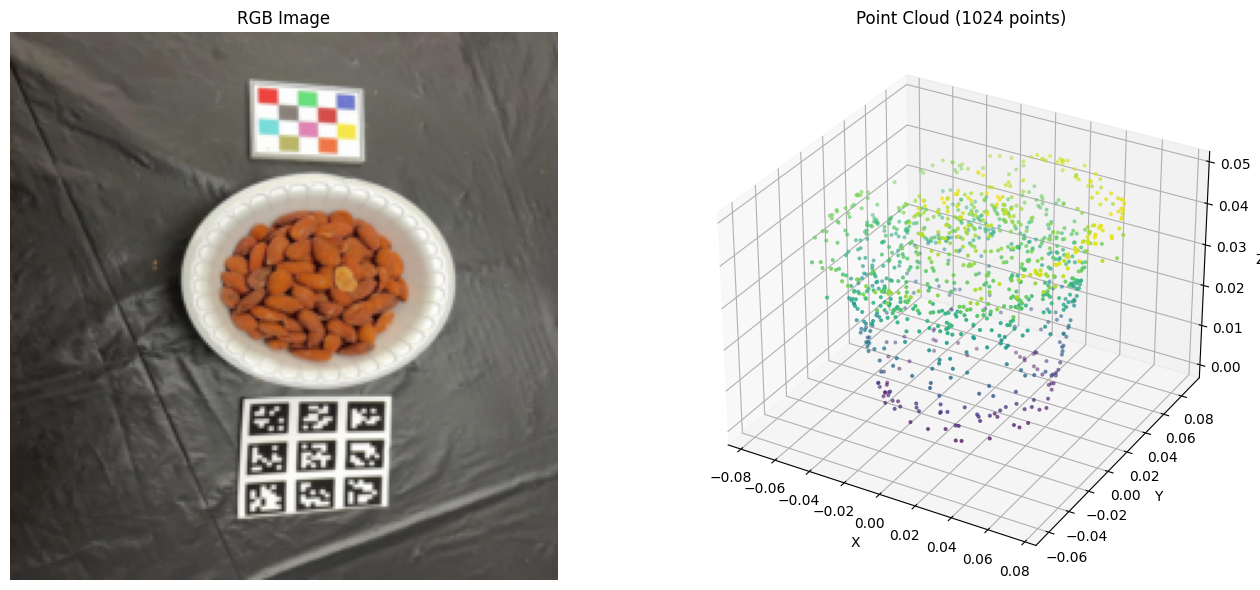

In [3]:
img_vis = np.transpose(image, (1, 2, 0))
img_vis = np.clip(img_vis, 0.0, 1.0)

fig = plt.figure(figsize=(14, 6))

# Image
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img_vis)
ax1.set_title('RGB Image')
ax1.axis('off')

# Point cloud
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(points[:, 0], points[:, 1], points[:, 2], s=4, c=points[:, 2], cmap='viridis')
ax2.set_title('Point Cloud (1024 points)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

plt.tight_layout()
plt.show()